# RCC Subtyping — Step 4: Evaluation & Error Analysis
### BME 515 Final Project (Person 3)

Goals:
1. Compare CLAM-SB vs CLAM-MB on the held-out test set.
2. Confidence / calibration analysis.
3. Error analysis focused on KICH (Chromophobe) vs Oncocytoma.
4. Attention heatmaps over original slide patches.

## 0) Setup, Paths, and Prediction Tables
Imports required libraries, defines project directories, prepares class mappings, and loads saved test-set predictions for CLAM-SB and CLAM-MB.

Expected output: selected device and the number of prediction rows loaded for each model.

In [1]:
from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
import cv2
from PIL import Image

BASE_DIR    = Path(r'C:\Users\raphi\Documents\BME515-RCC-Classification')
FEATURE_DIR = BASE_DIR / 'features' / 'features'
PATCH_DIR   = BASE_DIR / 'patches'
SLIDES_DIR  = BASE_DIR / 'slides'
CKPT_DIR    = BASE_DIR / 'checkpoints'
RESULT_DIR  = BASE_DIR / 'results'
FIG_DIR     = RESULT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True, parents=True)

CLASSES = ['Benign', 'Chromophobe', 'Clearcell', 'Oncocytoma', 'Papillary']
label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}
N_CLASSES = len(CLASSES)

device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

sb_pred = pd.read_csv(RESULT_DIR / 'clam_sb_test_predictions.csv')
mb_pred = pd.read_csv(RESULT_DIR / 'clam_mb_test_predictions.csv')
print('SB preds:', len(sb_pred), '   MB preds:', len(mb_pred))

device: cuda
SB preds: 73    MB preds: 73


## 1) Confusion Matrix Comparison (SB vs MB)
Builds row-normalized confusion matrices for CLAM-SB and CLAM-MB and displays raw counts as annotations.

This gives a quick class-wise view of where each model confuses subtypes.

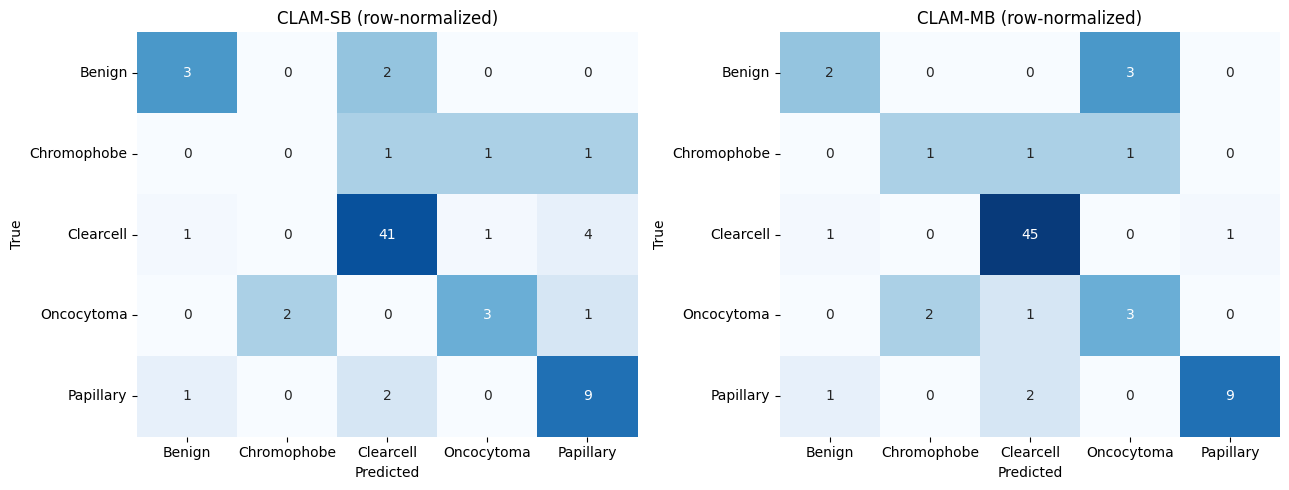

In [2]:
def plot_cm(preds, title, ax, normalize=True):
    y_true = preds['true_label'].map(label2idx).values
    y_pred = preds['pred_label'].map(label2idx).values
    cm = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
    disp = cm.astype(float)
    if normalize:
        row_sum = disp.sum(axis=1, keepdims=True)
        disp = np.divide(disp, row_sum, where=row_sum>0)
    sns.heatmap(disp, annot=cm, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                cbar=False, vmin=0, vmax=1 if normalize else None)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_cm(sb_pred, 'CLAM-SB (row-normalized)', axes[0])
plot_cm(mb_pred, 'CLAM-MB (row-normalized)', axes[1])
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrices.png', dpi=150)
plt.show()

## 2) Per-Class Precision/Recall/F1 Summary
Computes class-wise precision, recall, F1, and support for each model using a standardized classification report.

The resulting table is printed and exported to `results/per_class_summary.csv` for reporting.

In [3]:
def per_class_report(preds, name):
    y_true = preds['true_label'].map(label2idx).values
    y_pred = preds['pred_label'].map(label2idx).values
    rep = classification_report(y_true, y_pred, target_names=CLASSES,
                                 zero_division=0, output_dict=True)
    rows = []
    for c in CLASSES:
        rows.append({'model': name, 'class': c,
                     'precision': rep[c]['precision'],
                     'recall':    rep[c]['recall'],
                     'f1':        rep[c]['f1-score'],
                     'support':   int(rep[c]['support'])})
    return pd.DataFrame(rows)

summary = pd.concat([per_class_report(sb_pred, 'CLAM-SB'),
                     per_class_report(mb_pred, 'CLAM-MB')], ignore_index=True)
print(summary.to_string(index=False))
summary.to_csv(RESULT_DIR / 'per_class_summary.csv', index=False)

  model       class  precision   recall       f1  support
CLAM-SB      Benign   0.600000 0.600000 0.600000        5
CLAM-SB Chromophobe   0.000000 0.000000 0.000000        3
CLAM-SB   Clearcell   0.891304 0.872340 0.881720       47
CLAM-SB  Oncocytoma   0.600000 0.500000 0.545455        6
CLAM-SB   Papillary   0.600000 0.750000 0.666667       12
CLAM-MB      Benign   0.500000 0.400000 0.444444        5
CLAM-MB Chromophobe   0.333333 0.333333 0.333333        3
CLAM-MB   Clearcell   0.918367 0.957447 0.937500       47
CLAM-MB  Oncocytoma   0.428571 0.500000 0.461538        6
CLAM-MB   Papillary   0.900000 0.750000 0.818182       12


## 3) One-vs-Rest ROC Curves
Plots per-class one-vs-rest ROC curves for CLAM-SB and CLAM-MB using predicted class probabilities.

Saved figure: `results/figures/roc_ovr.png`.

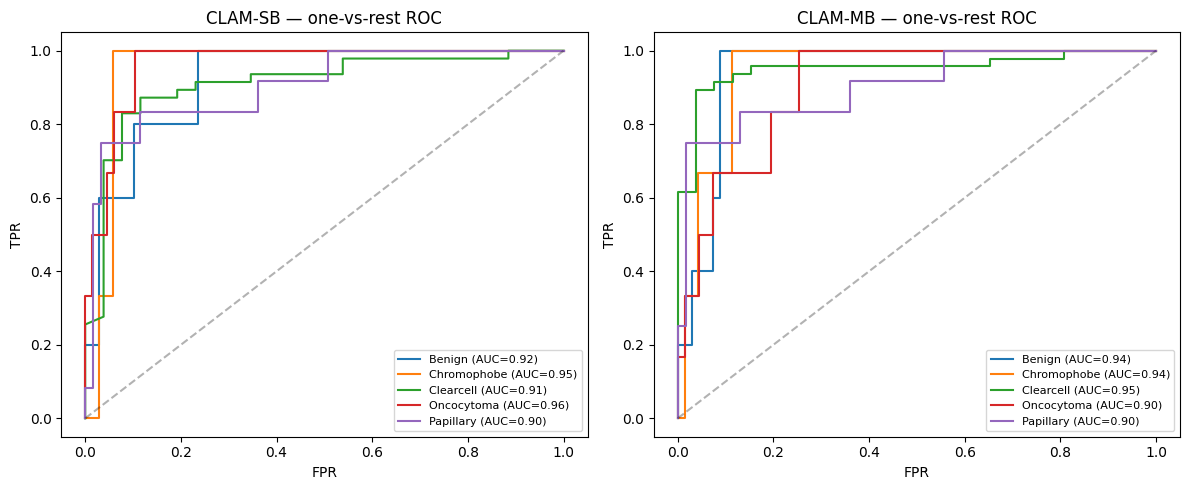

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, name in [(axes[0], sb_pred, 'CLAM-SB'),
                        (axes[1], mb_pred, 'CLAM-MB')]:
    y_true = preds['true_label'].map(label2idx).values
    for c, cname in idx2label.items():
        y_bin = (y_true == c).astype(int)
        if y_bin.sum() == 0: continue
        probs = preds[f'prob_{cname}'].values
        fpr, tpr, _ = roc_curve(y_bin, probs)
        auc = roc_auc_score(y_bin, probs)
        ax.plot(fpr, tpr, label=f'{cname} (AUC={auc:.2f})')
    ax.plot([0,1], [0,1], 'k--', alpha=0.3)
    ax.set_title(f'{name} — one-vs-rest ROC')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'roc_ovr.png', dpi=150)
plt.show()

## 4) Confidence Distribution (Correct vs Incorrect)
Compares confidence histograms between correctly and incorrectly classified slides for each model.

This helps assess overconfidence and error separation behavior.

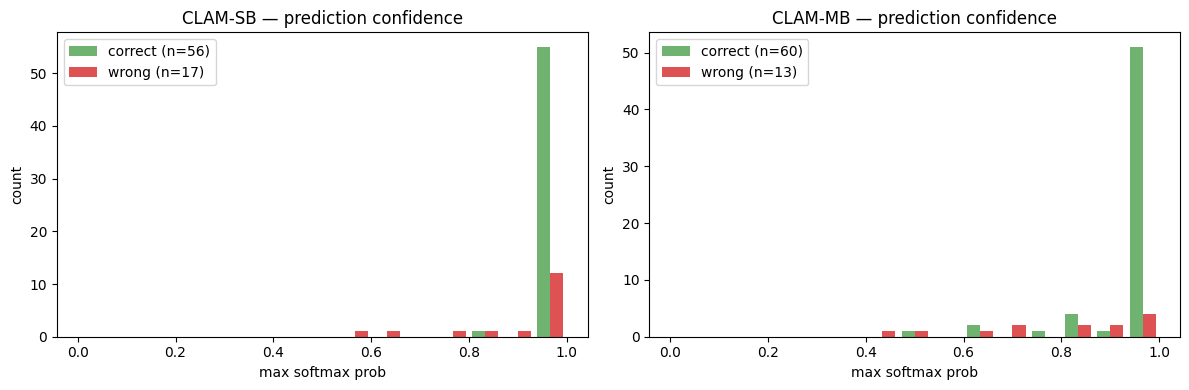


Mean confidence:
  CLAM-SB: correct 0.994 | wrong 0.921
  CLAM-MB: correct 0.956 | wrong 0.802


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, name in [(axes[0], sb_pred, 'CLAM-SB'),
                        (axes[1], mb_pred, 'CLAM-MB')]:
    corr = preds[preds.correct]['confidence']
    wrong = preds[~preds.correct]['confidence']
    ax.hist([corr, wrong], bins=15, range=(0,1),
            label=[f'correct (n={len(corr)})', f'wrong (n={len(wrong)})'],
            color=['#4c9f4c','#d62728'], alpha=0.8)
    ax.set_title(f'{name} — prediction confidence')
    ax.set_xlabel('max softmax prob'); ax.set_ylabel('count'); ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'confidence_hist.png', dpi=150)
plt.show()

print('\nMean confidence:')
for preds, name in [(sb_pred,'CLAM-SB'), (mb_pred,'CLAM-MB')]:
    print(f'  {name}: correct {preds[preds.correct].confidence.mean():.3f} | '
          f'wrong {preds[~preds.correct].confidence.mean():.3f}')

## 5) Reliability Plot (Calibration View)
Builds reliability diagrams by binning confidence and plotting empirical accuracy per bin.

Point size reflects bin sample count; the diagonal indicates perfect calibration.

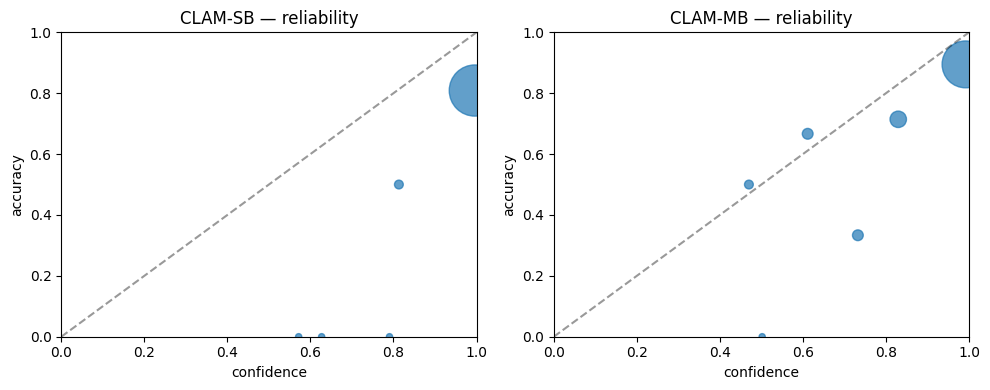

In [6]:
def reliability(preds, name, ax, n_bins=10):
    conf = preds['confidence'].values
    acc  = preds['correct'].values.astype(float)
    bins = np.linspace(0, 1, n_bins+1)
    binids = np.clip(np.digitize(conf, bins) - 1, 0, n_bins-1)
    xs, ys, ns = [], [], []
    for b in range(n_bins):
        mask = binids == b
        if mask.sum() == 0: continue
        xs.append(conf[mask].mean()); ys.append(acc[mask].mean()); ns.append(mask.sum())
    ax.plot([0,1],[0,1],'k--', alpha=0.4, label='perfect')
    ax.scatter(xs, ys, s=[n*20 for n in ns], alpha=0.7)
    ax.set_title(f'{name} — reliability')
    ax.set_xlabel('confidence'); ax.set_ylabel('accuracy'); ax.set_xlim(0,1); ax.set_ylim(0,1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
reliability(sb_pred, 'CLAM-SB', axes[0])
reliability(mb_pred, 'CLAM-MB', axes[1])
plt.tight_layout()
plt.savefig(FIG_DIR / 'reliability.png', dpi=150)
plt.show()

## 6) KICH vs Oncocytoma breakdown

In [7]:
def kich_onco_slice(preds, name):
    sub = preds[preds['true_label'].isin(['Chromophobe','Oncocytoma'])].copy()
    sub['model'] = name
    sub['direction'] = sub.apply(
        lambda r: 'correct' if r.correct
        else f'{r.true_label}->{r.pred_label}', axis=1)
    return sub

kich_onco = pd.concat([kich_onco_slice(sb_pred,'CLAM-SB'),
                       kich_onco_slice(mb_pred,'CLAM-MB')], ignore_index=True)

print('KICH <-> Oncocytoma confusion breakdown:')
print(kich_onco.groupby(['model','direction']).size().unstack(fill_value=0))
kich_onco.to_csv(RESULT_DIR / 'kich_onco_slice.csv', index=False)

KICH <-> Oncocytoma confusion breakdown:
direction  Chromophobe->Clearcell  Chromophobe->Oncocytoma  \
model                                                        
CLAM-MB                         1                        1   
CLAM-SB                         1                        1   

direction  Chromophobe->Papillary  Oncocytoma->Chromophobe  \
model                                                        
CLAM-MB                         0                        2   
CLAM-SB                         1                        2   

direction  Oncocytoma->Clearcell  Oncocytoma->Papillary  correct  
model                                                             
CLAM-MB                        1                      0        4  
CLAM-SB                        0                      1        3  


## 7) KICH vs Oncocytoma separability score

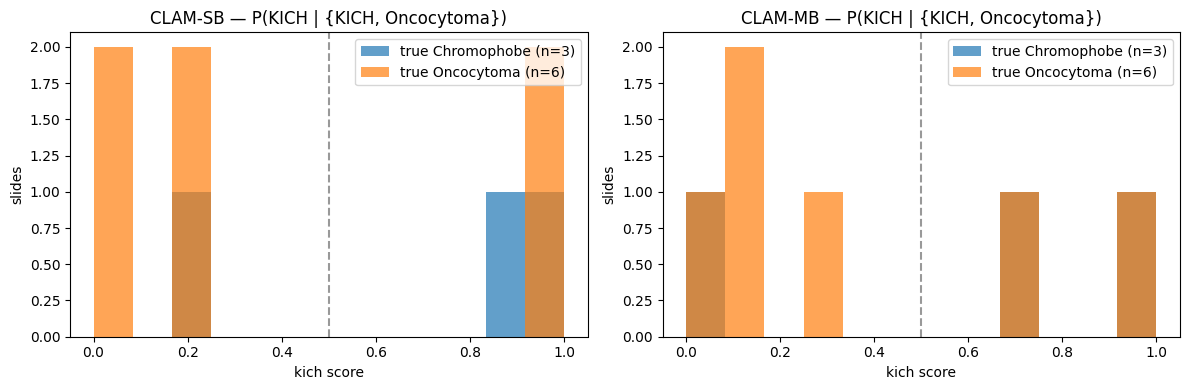

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, name in [(axes[0], sb_pred, 'CLAM-SB'),
                        (axes[1], mb_pred, 'CLAM-MB')]:
    sub = preds[preds['true_label'].isin(['Chromophobe','Oncocytoma'])].copy()
    sub['kich_score'] = sub['prob_Chromophobe'] / (sub['prob_Chromophobe'] + sub['prob_Oncocytoma'] + 1e-9)
    for lab, color in [('Chromophobe','#1f77b4'), ('Oncocytoma','#ff7f0e')]:
        vals = sub[sub['true_label']==lab]['kich_score'].values
        ax.hist(vals, bins=12, range=(0,1), alpha=0.7, label=f'true {lab} (n={len(vals)})', color=color)
    ax.axvline(0.5, color='k', linestyle='--', alpha=0.4)
    ax.set_title(f'{name} — P(KICH | {{KICH, Oncocytoma}})')
    ax.set_xlabel('kich score'); ax.set_ylabel('slides'); ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'kich_vs_onco_separability.png', dpi=150)
plt.show()

## 8) Re-declare CLAM for heatmaps

In [9]:
class GatedAttention(nn.Module):
    def __init__(self, in_dim, hidden=256, n_branches=1, dropout=0.25):
        super().__init__()
        self.attn_a = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh(), nn.Dropout(dropout))
        self.attn_b = nn.Sequential(nn.Linear(in_dim, hidden), nn.Sigmoid(), nn.Dropout(dropout))
        self.attn_c = nn.Linear(hidden, n_branches)
    def forward(self, h):
        a = self.attn_a(h) * self.attn_b(h)
        return self.attn_c(a)

class CLAM(nn.Module):
    def __init__(self, in_dim=2048, hidden=512, attn_hidden=256,
                 n_classes=5, k_sample=8, multi_branch=False, dropout=0.25):
        super().__init__()
        self.n_classes=n_classes; self.multi_branch=multi_branch
        n_branches = n_classes if multi_branch else 1
        self.fc = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout))
        self.attention = GatedAttention(hidden, attn_hidden, n_branches, dropout)
        if multi_branch:
            self.classifiers = nn.ModuleList([nn.Linear(hidden,1) for _ in range(n_classes)])
        else:
            self.classifier = nn.Linear(hidden, n_classes)
        self.instance_classifiers = nn.ModuleList([nn.Linear(hidden,2) for _ in range(n_classes)])

    @torch.no_grad()
    def attention_scores(self, h, target_class=None):
        """Return softmaxed attention weights for visualization."""
        h = self.fc(h)
        A = self.attention(h).transpose(1, 0)
        A = F.softmax(A, dim=1)
        if self.multi_branch and target_class is not None:
            return A[target_class].cpu().numpy()
        return A[0].cpu().numpy()

    @torch.no_grad()
    def predict(self, h):
        h_proj = self.fc(h)
        A = self.attention(h_proj).transpose(1,0)
        A = F.softmax(A, dim=1)
        if self.multi_branch:
            M = A @ h_proj
            logits = torch.cat([self.classifiers[c](M[c:c+1]) for c in range(self.n_classes)], dim=1)
        else:
            M = A @ h_proj
            logits = self.classifier(M)
        return F.softmax(logits, dim=1).cpu().numpy().ravel()

def load_model(name, multi_branch):
    m = CLAM(multi_branch=multi_branch).to(device)
    m.load_state_dict(torch.load(CKPT_DIR / f'{name}_best.pt', map_location=device))
    m.eval()
    return m

sb_model = load_model('clam_sb', multi_branch=False)
mb_model = load_model('clam_mb', multi_branch=True)

### Heatmap helper functions

In [10]:
def parse_patch_xy(patch_name):
    """Return (y,x) coords from the patch filename. Falls back to index order."""
    m = re.search(r'y(\d+)_x(\d+)', patch_name)
    if m: return int(m.group(1)), int(m.group(2))
    m = re.search(r'_(\d+)_(\d+)', patch_name)
    if m: return int(m.group(1)), int(m.group(2))
    return None, None

def build_heatmap(slide_id, attn_weights, patch_size=256):
    """Lay out per-patch attention on a grid matching the slide."""
    patch_paths = sorted((PATCH_DIR / slide_id).glob('*.png'))
    assert len(patch_paths) == len(attn_weights), \
        f'{slide_id}: {len(patch_paths)} patches vs {len(attn_weights)} weights'

    coords = [parse_patch_xy(p.name) for p in patch_paths]
    if any(c[0] is None for c in coords):
        return np.array(attn_weights).reshape(1, -1), None

    ys = np.array([c[0] for c in coords])
    xs = np.array([c[1] for c in coords])
    stride_y = np.min(np.diff(np.unique(ys))) if len(np.unique(ys))>1 else patch_size
    stride_x = np.min(np.diff(np.unique(xs))) if len(np.unique(xs))>1 else patch_size
    rows = (ys - ys.min()) // stride_y
    cols = (xs - xs.min()) // stride_x
    H, W = rows.max()+1, cols.max()+1
    grid = np.zeros((H, W), dtype=np.float32)
    for r, c, w in zip(rows, cols, attn_weights):
        grid[r, c] = w
    return grid, (ys.min(), xs.min(), stride_y, stride_x)

def visualize_slide_attention(slide_id, model, true_label, ax_img, ax_heat, ax_overlay,
                              target_class=None):
    feats = torch.load(FEATURE_DIR / f'{slide_id}.pt', weights_only=True).float().to(device)
    if feats.ndim == 3: feats = feats.view(feats.size(0), -1)
    probs = model.predict(feats)
    pred = int(np.argmax(probs))
    tc = target_class if target_class is not None else pred
    attn = model.attention_scores(feats, target_class=tc)
    attn_norm = (attn - attn.min()) / (attn.max() - attn.min() + 1e-9)

    grid, info = build_heatmap(slide_id, attn_norm)
    slide_path = SLIDES_DIR / f'{slide_id}.png'
    if slide_path.exists():
        img = cv2.cvtColor(cv2.imread(str(slide_path)), cv2.COLOR_BGR2RGB)
        ax_img.imshow(img); ax_img.set_title(f'{slide_id}\ntrue={true_label}')
        hm = cv2.resize(grid, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_CUBIC)
        ax_overlay.imshow(img)
        ax_overlay.imshow(hm, cmap='jet', alpha=0.45, vmin=0, vmax=1)
        ax_overlay.set_title(f'attn overlay ({idx2label[tc]})')
    else:
        ax_img.text(0.5,0.5,'slide image not found', ha='center'); ax_img.axis('off')
        ax_overlay.axis('off')

    ax_heat.imshow(grid, cmap='jet', vmin=0, vmax=1)
    ax_heat.set_title(f'attn grid\npred={idx2label[pred]} p={probs[pred]:.2f}')
    for a in (ax_img, ax_heat, ax_overlay): a.axis('off')
    return pred, probs

## 9) Select misclassified KICH / Oncocytoma slides

In [11]:
candidates = mb_pred[
    (mb_pred['true_label'].isin(['Chromophobe','Oncocytoma'])) & (~mb_pred['correct'])
].sort_values('confidence', ascending=False)
print(f'Found {len(candidates)} KICH/Oncocytoma errors in CLAM-MB:')
print(candidates[['slide_id','true_label','pred_label','confidence']].to_string(index=False))

correct_examples = mb_pred[
    (mb_pred['true_label'].isin(['Chromophobe','Oncocytoma'])) & (mb_pred.correct)
].sort_values('confidence', ascending=False).head(2)

Found 5 KICH/Oncocytoma errors in CLAM-MB:
 slide_id  true_label  pred_label  confidence
DHMC_0111  Oncocytoma Chromophobe    0.962700
DHMC_0040 Chromophobe  Oncocytoma    0.929973
DHMC_0103  Oncocytoma   Clearcell    0.726179
DHMC_0049 Chromophobe   Clearcell    0.602368
DHMC_0409  Oncocytoma Chromophobe    0.445597


In [25]:
import h5py

def load_features_h5(slide_id):
    """Load features from h5, matching the dataset class logic."""
    h5_path = FEATURE_DIR / f"{slide_id}.h5"
    with h5py.File(h5_path, "r") as f:
        for k in ["features", "feats", "x", "embeddings"]:
            if k in f:
                arr = f[k][:]
                break
        else:
            keys = list(f.keys())
            arr = f[keys[0]][:]
    feats = torch.from_numpy(np.asarray(arr))
    if feats.ndim == 3:
        feats = feats.view(feats.size(0), -1)
    return feats.float()

def visualize_slide_attention(slide_id, model, true_label, ax_img, ax_heat, ax_overlay,
                              target_class=None):
    """Spatial attention heatmap with patch files (h5 features)."""
    h5_path = FEATURE_DIR / f'{slide_id}.h5'
    if not h5_path.exists():
        for a in (ax_img, ax_heat, ax_overlay):
            a.text(0.5, 0.5, f'{slide_id}\nh5 not found', ha='center', va='center'); a.axis('off')
        return None, None

    feats = load_features_h5(slide_id).to(device)
    probs = model.predict(feats)
    pred = int(np.argmax(probs))
    tc = target_class if target_class is not None else pred
    attn = model.attention_scores(feats, target_class=tc)
    attn_norm = (attn - attn.min()) / (attn.max() - attn.min() + 1e-9)

    grid, info = build_heatmap(slide_id, attn_norm)
    slide_path = SLIDES_DIR / f'{slide_id}.png'
    if slide_path.exists():
        img = cv2.cvtColor(cv2.imread(str(slide_path)), cv2.COLOR_BGR2RGB)
        ax_img.imshow(img); ax_img.set_title(f'{slide_id}\ntrue={true_label}')
        hm = cv2.resize(grid, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_CUBIC)
        ax_overlay.imshow(img)
        ax_overlay.imshow(hm, cmap='jet', alpha=0.45, vmin=0, vmax=1)
        ax_overlay.set_title(f'attn overlay ({idx2label[tc]})')
    else:
        ax_img.text(0.5,0.5,'slide image not found', ha='center'); ax_img.axis('off')
        ax_overlay.axis('off')

    ax_heat.imshow(grid, cmap='jet', vmin=0, vmax=1)
    ax_heat.set_title(f'attn grid\npred={idx2label[pred]} p={probs[pred]:.2f}')
    for a in (ax_img, ax_heat, ax_overlay): a.axis('off')
    return pred, probs

def show_top_patches(slide_id, model, target_class, k=6, title_prefix=''):
    """Show k highest-attention patches as image strip."""
    feats = load_features_h5(slide_id).to(device)
    attn = model.attention_scores(feats, target_class=target_class)
    patch_paths = sorted((PATCH_DIR / slide_id).glob('*.png'))
    top_idx = np.argsort(-attn)[:k]
    fig, axes = plt.subplots(1, k, figsize=(2.2*k, 2.5))
    for i, idx in enumerate(top_idx):
        img = cv2.cvtColor(cv2.imread(str(patch_paths[idx])), cv2.COLOR_BGR2RGB)
        axes[i].imshow(img); axes[i].axis('off')
        axes[i].set_title(f'a={attn[idx]:.3f}\n{patch_paths[idx].name}', fontsize=6)
    plt.suptitle(f'{title_prefix}{slide_id} — top-{k} patches (attn toward {idx2label[target_class]})',
                 fontsize=10)
    plt.tight_layout()
    return fig

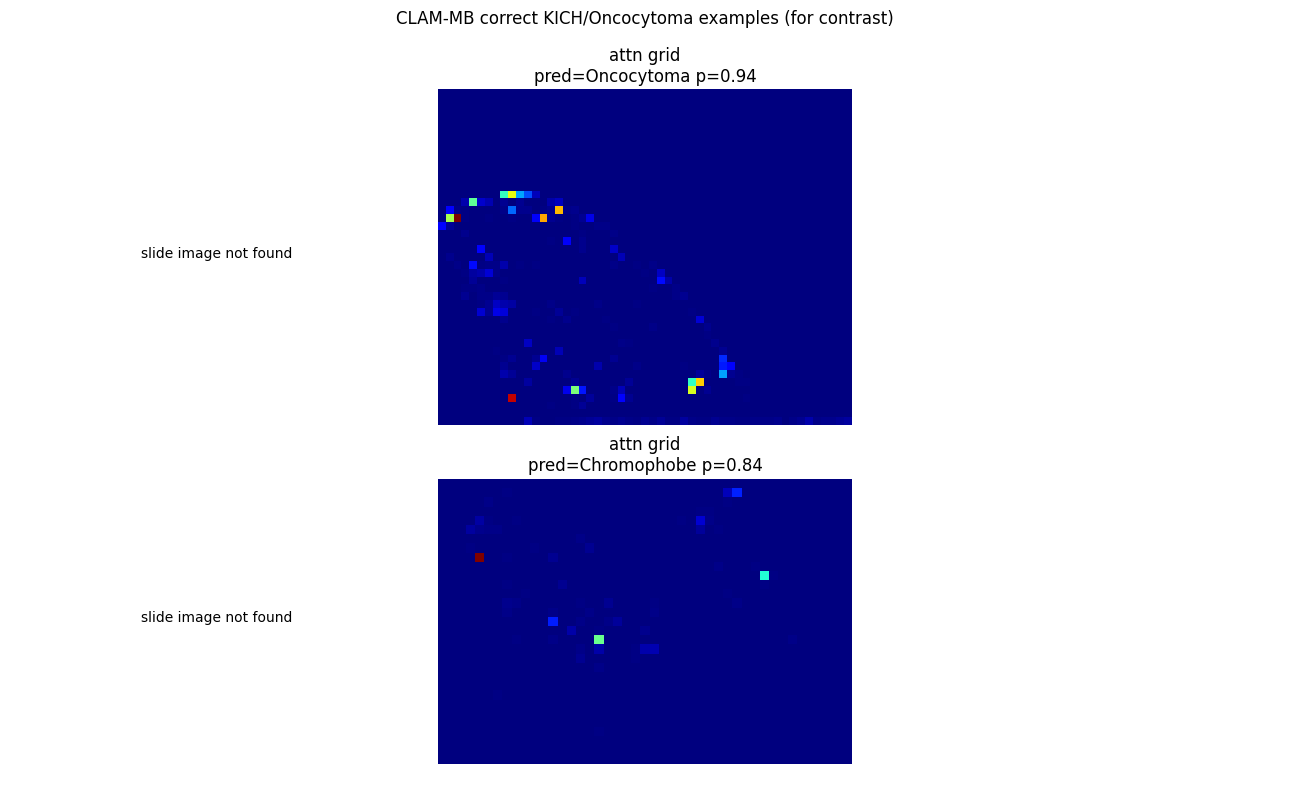

In [26]:
if len(correct_examples) > 0:
    n = len(correct_examples)
    fig, axes = plt.subplots(n, 3, figsize=(13, 4*n))
    if n == 1: axes = axes[None, :]
    for i, (_, row) in enumerate(correct_examples.iterrows()):
        tc = label2idx[row.true_label]
        visualize_slide_attention(row.slide_id, mb_model, row.true_label,
                                   axes[i,0], axes[i,1], axes[i,2], target_class=tc)
    plt.suptitle('CLAM-MB correct KICH/Oncocytoma examples (for contrast)',
                 y=1.002, fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'heatmaps_correct.png', dpi=150, bbox_inches='tight')
    plt.show()

In [14]:
# -------- Attention analysis WITHOUT patch files --------
# Use these when patches/ isn't available locally.
# Same inputs as the patch-based versions, but plots attention distributions
# instead of spatial overlays.

def visualize_slide_attention_nopatches(slide_id, model, true_label,
                                        ax_sorted, ax_hist,
                                        target_class=None):
    """Attention analysis without patch files — shows attention distribution shape."""
    feats = load_features_h5(slide_id).to(device)
    probs = model.predict(feats)
    pred = int(np.argmax(probs))
    tc = target_class if target_class is not None else pred
    attn = model.attention_scores(feats, target_class=tc)

    # attention entropy as a measure of how peaked vs. diffuse the model's focus is
    attn_safe = np.clip(attn, 1e-12, None)
    entropy = float(-(attn_safe * np.log(attn_safe)).sum())
    max_entropy = float(np.log(len(attn)))  # uniform attention over N patches
    norm_entropy = entropy / max_entropy if max_entropy > 0 else 0

    # left: sorted attention weights — shape tells you "attending to a few" vs "spread out"
    ax_sorted.plot(sorted(attn, reverse=True), linewidth=1.5)
    ax_sorted.set_title(f'{slide_id}  (true={true_label})\n'
                        f'sorted attn toward {idx2label[tc]}  |  norm-entropy={norm_entropy:.2f}',
                        fontsize=9)
    ax_sorted.set_xlabel(f'patch rank (of {len(attn)})'); ax_sorted.set_ylabel('attention')
    ax_sorted.grid(alpha=0.3)

    # right: histogram
    ax_hist.hist(attn, bins=40, color='steelblue', edgecolor='white')
    ax_hist.set_title(f'pred={idx2label[pred]} p={probs[pred]:.2f}', fontsize=9)
    ax_hist.set_xlabel('attention weight'); ax_hist.set_ylabel('# patches')

    return pred, probs, norm_entropy


def show_top_patches_nopatches(slide_id, model, target_class, k=10, title_prefix=''):
    """Without patch images, we can't show top patches — but we can show their
    attention values and patch indices, which you can later cross-reference
    if patch files become available."""
    feats = load_features_h5(slide_id).to(device)
    attn = model.attention_scores(feats, target_class=target_class)
    top_idx = np.argsort(-attn)[:k]
    bot_idx = np.argsort(attn)[:k]

    fig, ax = plt.subplots(figsize=(8, 3))
    x = np.arange(k)
    width = 0.4
    ax.bar(x - width/2, attn[top_idx], width, label='top-k', color='#d62728')
    ax.bar(x + width/2, attn[bot_idx], width, label='bottom-k', color='#1f77b4')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{t}\nvs\n{b}' for t, b in zip(top_idx, bot_idx)], fontsize=7)
    ax.set_xlabel('patch index (top / bottom)')
    ax.set_ylabel('attention weight')
    ax.set_title(f'{title_prefix}{slide_id} — top-{k} vs bottom-{k} attended patches '
                 f'(toward {idx2label[target_class]})', fontsize=10)
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    return fig

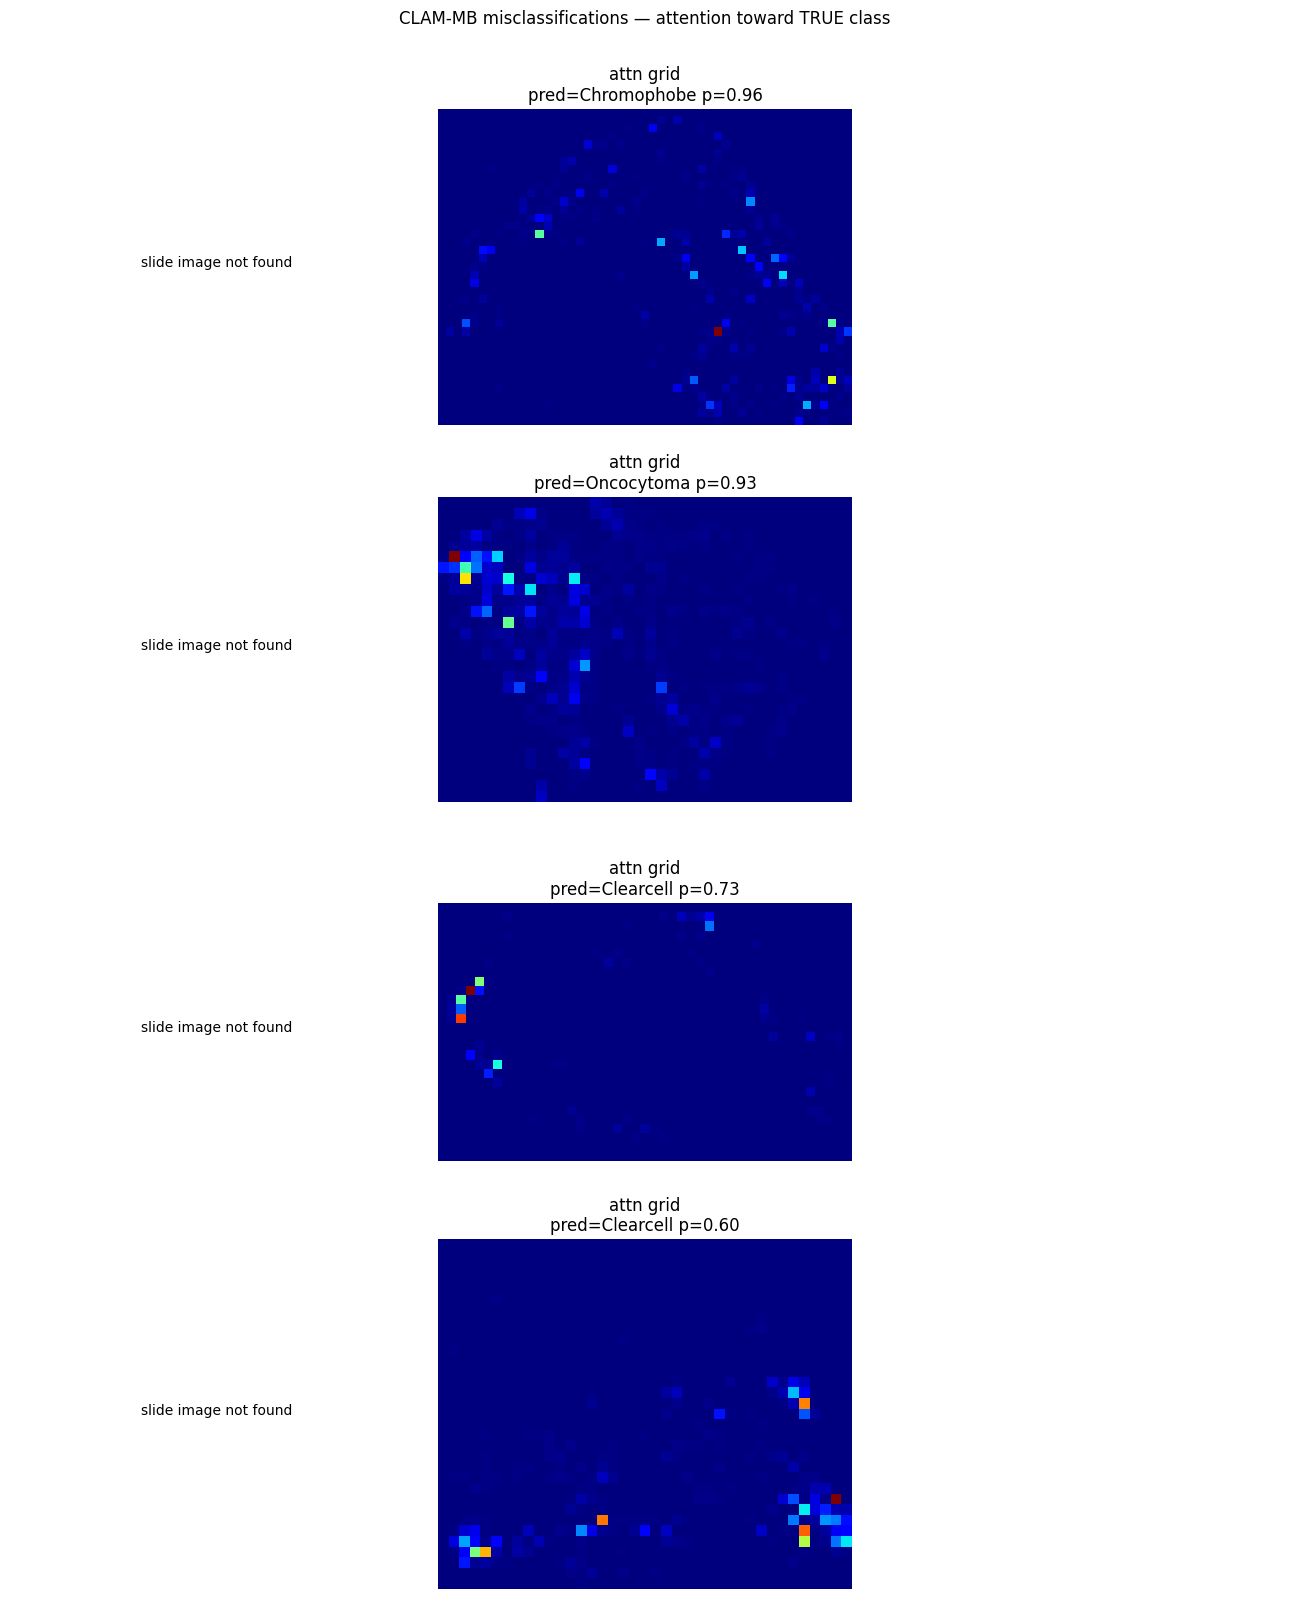

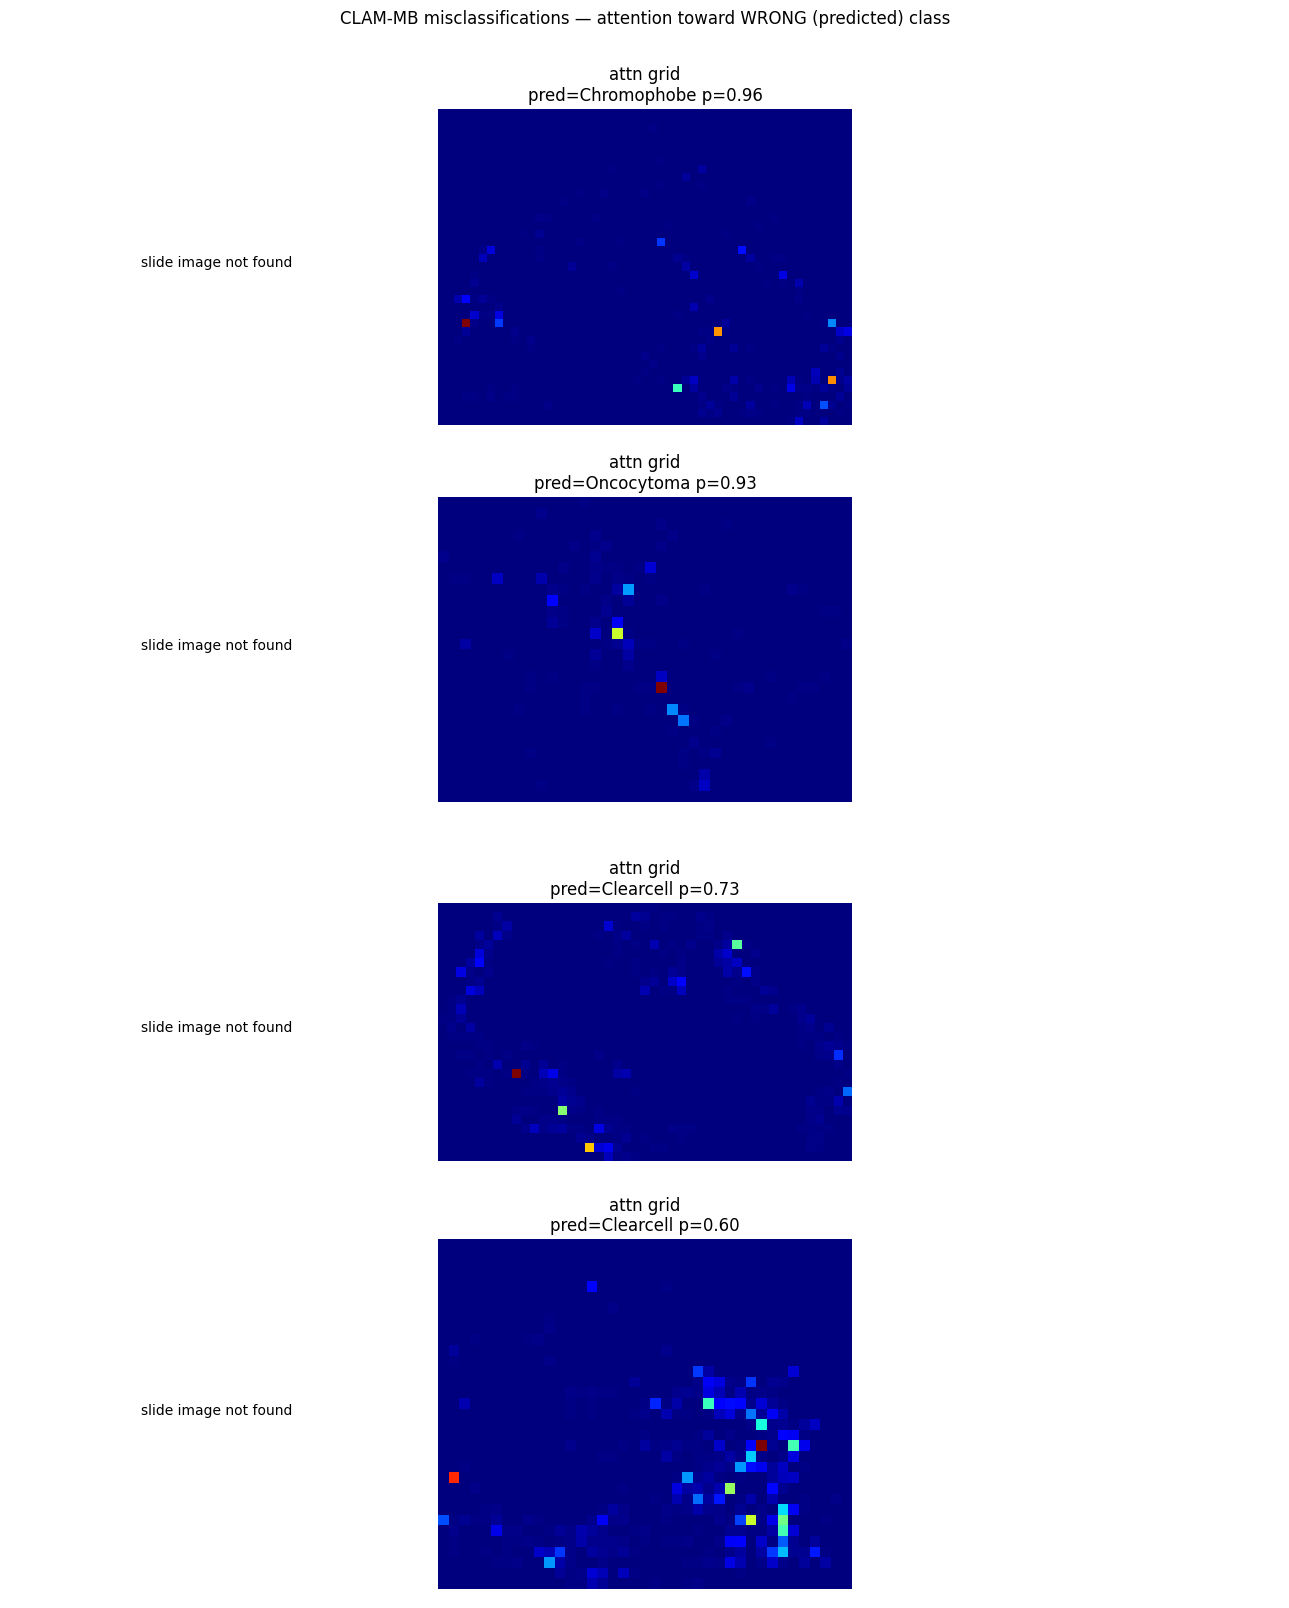

In [27]:
to_show = candidates.head(4)
n = len(to_show)
if n > 0:
    fig, axes = plt.subplots(n, 3, figsize=(13, 4*n))
    if n == 1: axes = axes[None, :]
    for i, (_, row) in enumerate(to_show.iterrows()):
        tc = label2idx[row.true_label]
        visualize_slide_attention(row.slide_id, mb_model, row.true_label,
                                   axes[i,0], axes[i,1], axes[i,2], target_class=tc)
    plt.suptitle('CLAM-MB misclassifications — attention toward TRUE class',
                 y=1.002, fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'heatmaps_errors_true_class.png', dpi=150, bbox_inches='tight')
    plt.show()

    fig, axes = plt.subplots(n, 3, figsize=(13, 4*n))
    if n == 1: axes = axes[None, :]
    for i, (_, row) in enumerate(to_show.iterrows()):
        pc = label2idx[row.pred_label]
        visualize_slide_attention(row.slide_id, mb_model, row.true_label,
                                   axes[i,0], axes[i,1], axes[i,2], target_class=pc)
    plt.suptitle('CLAM-MB misclassifications — attention toward WRONG (predicted) class',
                 y=1.002, fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'heatmaps_errors_pred_class.png', dpi=150, bbox_inches='tight')
    plt.show()

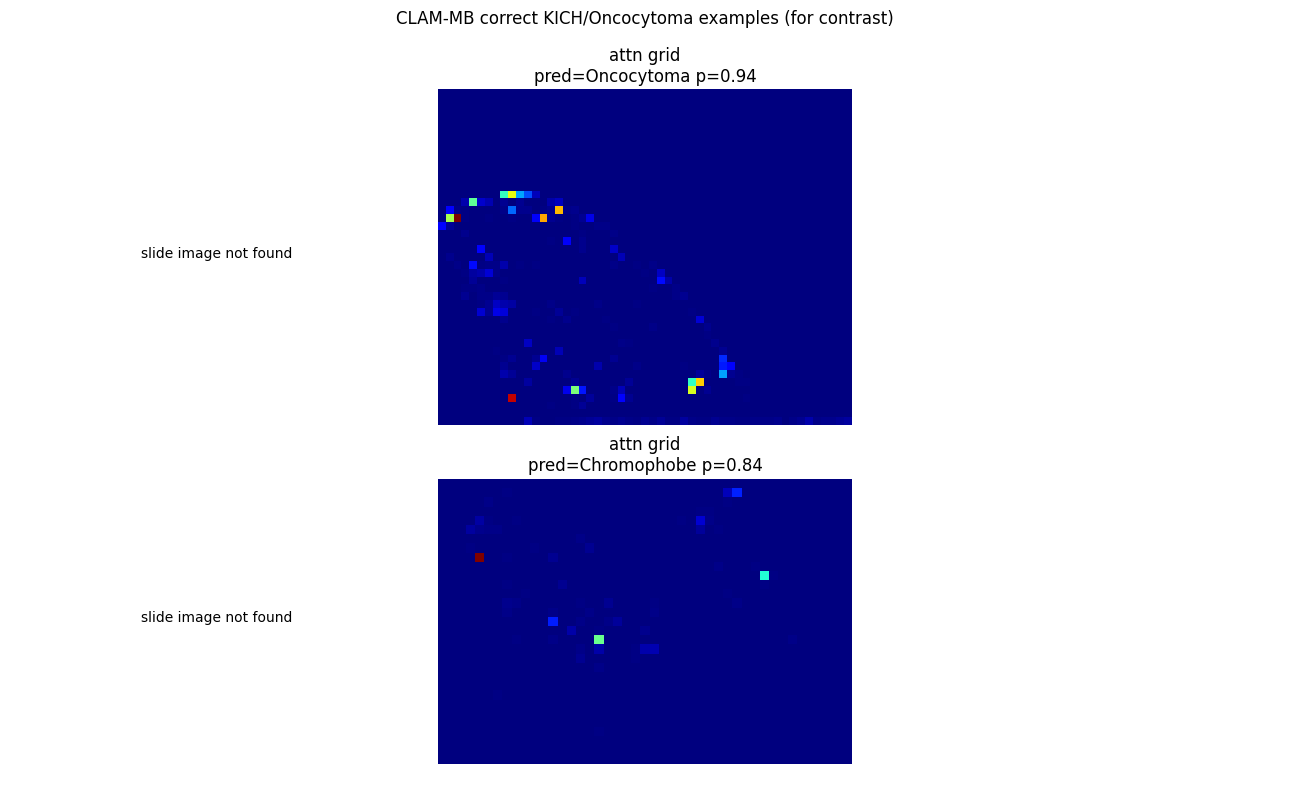

In [23]:
if len(correct_examples) > 0:
    n = len(correct_examples)
    fig, axes = plt.subplots(n, 3, figsize=(13, 4*n))
    if n == 1: axes = axes[None, :]
    for i, (_, row) in enumerate(correct_examples.iterrows()):
        tc = label2idx[row.true_label]
        visualize_slide_attention(row.slide_id, mb_model, row.true_label,
                                   axes[i,0], axes[i,1], axes[i,2], target_class=tc)
    plt.suptitle('CLAM-MB correct KICH/Oncocytoma examples (for contrast)',
                 y=1.002, fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'heatmaps_correct.png', dpi=150, bbox_inches='tight')
    plt.show()

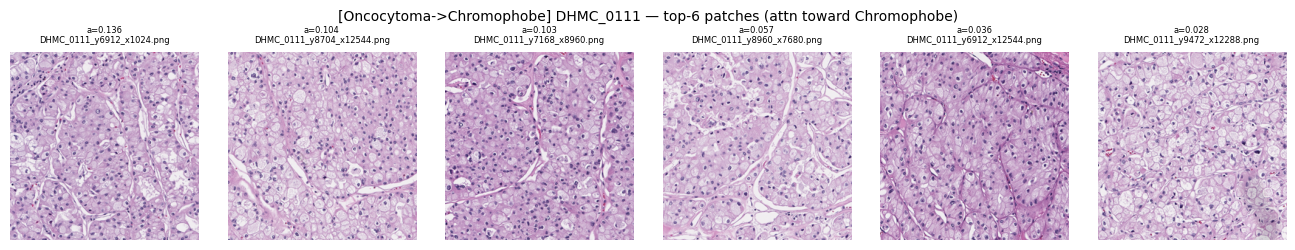

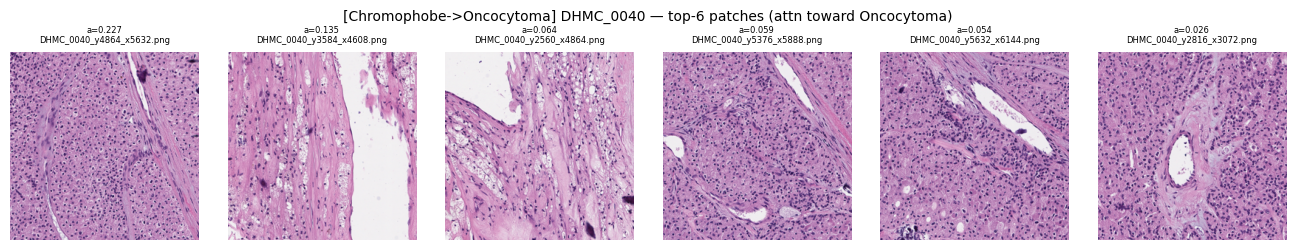

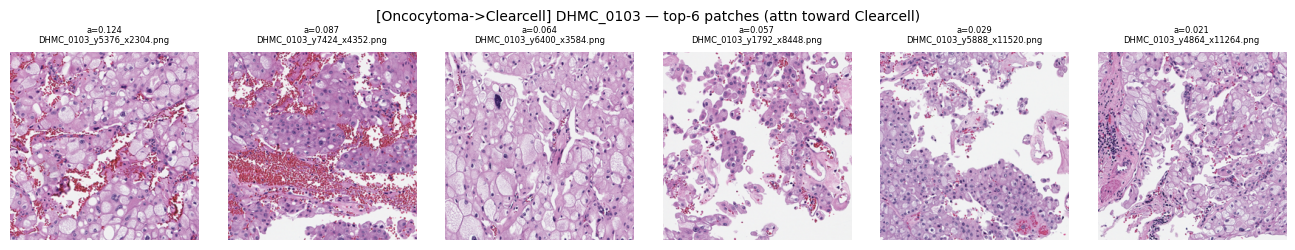

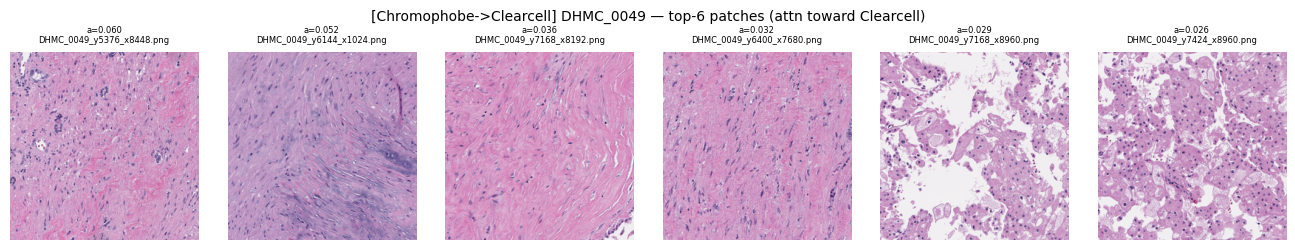

In [28]:
for _, row in to_show.iterrows():
    f = show_top_patches(row.slide_id, mb_model,
                         target_class=label2idx[row.pred_label],
                         title_prefix=f'[{row.true_label}->{row.pred_label}] ')
    f.savefig(FIG_DIR / f'top_patches_{row.slide_id}_pred.png', dpi=150, bbox_inches='tight')
    plt.show()